import important libraries

In [1]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

In [2]:
# Load the saved data
data = np.load("raw_eye_data.npz")
X = data["X"]
y = data["y"]

# Check the shapes of the loaded data
print("X shape:", X.shape)
print("y shape:", y.shape)

fs = 250

X shape: (107, 8, 250)
y shape: (107,)


PSD (Power Spectral Density Analysis)

Open PSD count : 408
Closed PSD count: 448


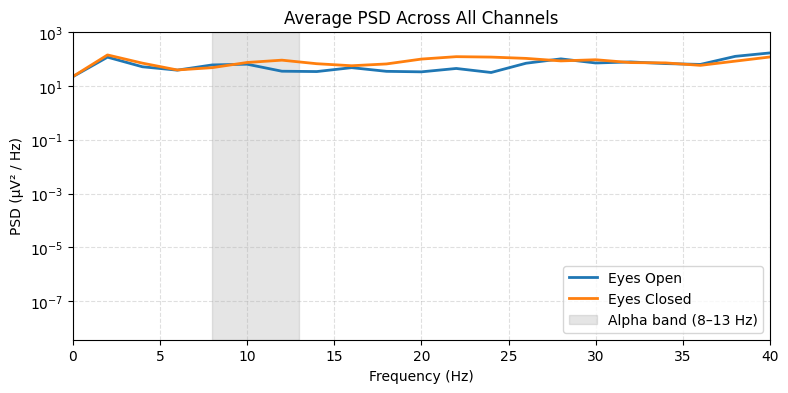

In [3]:
psd_open = []
psd_closed = []

for i in range(len(X)):
    for ch in range(X.shape[1]):
        signal = X[i][ch]  # (250,)
        f, pxx = welch(signal, fs=fs, nperseg=fs // 2)

        if y[i] == 1:      # Eyes open
            psd_open.append(pxx)
        elif y[i] == 2:    # Eyes closed
            psd_closed.append(pxx)

psd_open = np.array(psd_open)
psd_closed = np.array(psd_closed)

print("Open PSD count :", psd_open.shape[0])
print("Closed PSD count:", psd_closed.shape[0])

# --------------------------------------------------
# Average PSDs
# --------------------------------------------------
mean_psd_open = psd_open.mean(axis=0)
mean_psd_closed = psd_closed.mean(axis=0)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 4))

plt.semilogy(f, mean_psd_open, label="Eyes Open", linewidth=2)
plt.semilogy(f, mean_psd_closed, label="Eyes Closed", linewidth=2)

# Highlight alpha band
plt.axvspan(8, 13, color="gray", alpha=0.2, label="Alpha band (8–13 Hz)")

plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV² / Hz)")
plt.title("Average PSD Across All Channels")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.show()

In [4]:
def extract_features(signal, fs=250):
    # --- PSD ---
    f, pxx = welch(signal, fs=fs, nperseg=fs)

    # Frequency bands
    delta_idx = (f >= 1) & (f < 4)
    theta_idx = (f >= 4) & (f < 8)
    alpha_idx = (f >= 8) & (f < 13)
    beta_idx  = (f >= 13) & (f < 30)

    delta = np.trapezoid(pxx[delta_idx], f[delta_idx])
    theta = np.trapezoid(pxx[theta_idx], f[theta_idx])
    alpha = np.trapezoid(pxx[alpha_idx], f[alpha_idx])
    beta  = np.trapezoid(pxx[beta_idx],  f[beta_idx])

    # --- Relative band powers (delta excluded on purpose) ---
    total_power = theta + alpha + beta + 1e-10
    rel_delta = delta / total_power
    rel_theta = theta / total_power
    rel_alpha = alpha / total_power
    rel_beta  = beta  / total_power

    # --- Band ratio ---
    alpha_beta_ratio = alpha / (beta + 1e-10)

    # --- Spectral entropy ---
    psd_norm = pxx / (np.sum(pxx) + 1e-10)
    spectral_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-10))

    # --- Hjorth parameters ---
    var = np.var(signal)

    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var_diff1 = np.var(diff1)
    var_diff2 = np.var(diff2)

    mobility = np.sqrt(var_diff1 / (var + 1e-10))
    complexity = np.sqrt(var_diff2 / (var_diff1 + 1e-10)) / (mobility + 1e-10)

    # New Test Features
    mobility_theta = np.sqrt(np.var(np.diff(signal)) / (theta + 1e-10))
    complexity_theta = np.sqrt(np.var(np.diff(np.diff(signal))) / (theta + 1e-10)) / (mobility_theta + 1e-10)

    mobility_alpha = np.sqrt(np.var(np.diff(signal)) / (alpha + 1e-10))
    complexity_alpha = np.sqrt(np.var(np.diff(np.diff(signal))) / (alpha + 1e-10)) / (mobility_alpha + 1e-10)

    mobility_beta = np.sqrt(np.var(np.diff(signal)) / (beta + 1e-10))
    complexity_beta = np.sqrt(np.var(np.diff(np.diff(signal))) / (beta + 1e-10)) / (mobility_beta + 1e-10)

    #Extra Features
    mean_signal = np.mean(signal)
    std_signal = np.std(signal)
    max_signal = np.max(signal)
    min_signal = np.min(signal)


    # --- Log scaling where appropriate ---
    return (
        np.log(theta + 1e-10),
        np.log(alpha + 1e-10),
        np.log(beta  + 1e-10),
        np.log(rel_theta + 1e-10),
        np.log(rel_alpha + 1e-10),
        np.log(rel_beta  + 1e-10),
        np.log(alpha_beta_ratio + 1e-10),
        np.log(var + 1e-10),
        mobility,
        complexity,
        spectral_entropy,
        mobility_theta,
        complexity_theta,
        mobility_alpha,
        complexity_alpha,
        mobility_beta,
        complexity_beta,
        mean_signal,
        std_signal,
        max_signal,
        min_signal
    )

In [5]:
new_X = []
for i in range (len(X)):
    features = []
    for ch in range(X.shape[1]):
        signal = X[i][ch]
        features.extend(extract_features(signal, fs))
    new_X.append(features)

new_X = np.array(new_X)
print("New feature shape:", new_X.shape)

np.savez(
    "processed_eye_data.npz",
    X=new_X,
    y=y,
    fs=fs
)

New feature shape: (107, 168)
